完成作业后，请运行所有单元格，并将 notebook 保存为 PDF 用于 Gradescope 提交（可按 Ctrl-P 或 Cmd-P 打印）。请确保图片不要被分页截断；如有必要，请在打印 PDF 前插入文本单元格来调整分页。


姓名：许政阳  
学号：231880081  
合作者：无

---




# **作业 3：三维重建**

# 问题 1：理论（20 分）


## 1.1 [10 分]
请参见 PDF 中的题目。




### Q1.1 证明

**题目：** 假设两个相机都注视空间中的同一个三维点 $\mathbf{X}$，且该三维点在两张图像中的投影都位于像素坐标 $(0, 0)$，证明基础矩阵 $F$ 的 $f_{33}$ 元素必须为 $0$。

**证明：**

基础矩阵 $F$ 定义了对极约束：

$$\mathbf{x}'^{\top} F \, \mathbf{x} = 0$$

由题意，三维点 $\mathbf{X}$ 在两张图像中的投影都位于像素坐标 $(0,0)$，因此其齐次坐标为：

$$\mathbf{x} = \begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}, \quad \mathbf{x}' = \begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}$$

将基础矩阵 $F$ 展开为各元素：

$$F = \begin{pmatrix} f_{11} & f_{12} & f_{13} \\ f_{21} & f_{22} & f_{23} \\ f_{31} & f_{32} & f_{33} \end{pmatrix}$$

代入对极约束：

$$\mathbf{x}'^{\top} F \, \mathbf{x} = \begin{pmatrix} 0 & 0 & 1 \end{pmatrix} \begin{pmatrix} f_{11} & f_{12} & f_{13} \\ f_{21} & f_{22} & f_{23} \\ f_{31} & f_{32} & f_{33} \end{pmatrix} \begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}$$

计算 $F\,\mathbf{x}$：

$$F\,\mathbf{x} = \begin{pmatrix} f_{13} \\ f_{23} \\ f_{33} \end{pmatrix}$$

再计算 $\mathbf{x}'^{\top}(F\,\mathbf{x})$：

$$\mathbf{x}'^{\top} F\,\mathbf{x} = 0 \cdot f_{13} + 0 \cdot f_{23} + 1 \cdot f_{33} = f_{33}$$

由对极约束 $\mathbf{x}'^{\top} F \, \mathbf{x} = 0$，因此：

$$\boxed{f_{33} = 0}$$

$\blacksquare$


## 1.2 [10 分]
请参见 PDF 中的题目。


### Q1.2 解答

**题目：** 假设一个机器人携带惯性传感器运动，传感器在时刻 $i$ 报告机器人在全局坐标系中的绝对旋转 $R_i$ 和平移 $t_i$。求相对旋转 $R_{\text{rel}}$ 和相对平移 $t_{\text{rel}}$，并用 $K$、$R_{\text{rel}}$、$t_{\text{rel}}$ 表示 $E$ 和 $F$。

---

**第一部分：求 $R_{\text{rel}}$ 和 $t_{\text{rel}}$**

传感器报告的全局位姿 $(R_i, t_i)$ 表示从相机坐标系到全局坐标系的变换。对于全局坐标系中的一个三维点 $\mathbf{P}_w$，其在相机 $i$ 坐标系中的表示为：

$$\mathbf{P}_i = R_i^{\top}(\mathbf{P}_w - t_i)$$

从相机 $i$ 坐标系恢复全局坐标：$\mathbf{P}_w = R_i \mathbf{P}_i + t_i$

代入相机 $i+1$ 的表达式：

$$\mathbf{P}_{i+1} = R_{i+1}^{\top}(R_i \mathbf{P}_i + t_i - t_{i+1}) = R_{i+1}^{\top} R_i \, \mathbf{P}_i + R_{i+1}^{\top}(t_i - t_{i+1})$$

因此：

$$\boxed{R_{\text{rel}} = R_{i+1}^{\top} R_i}$$

$$\boxed{t_{\text{rel}} = R_{i+1}^{\top}(t_i - t_{i+1})}$$

---

**第二部分：用 $K$、$R_{\text{rel}}$、$t_{\text{rel}}$ 表示 $E$ 和 $F$**

本质矩阵：

$$\boxed{E = [t_{\text{rel}}]_{\times} \, R_{\text{rel}}}$$

其中 $[t_{\text{rel}}]_{\times}$ 是 $t_{\text{rel}}$ 的反对称矩阵。

基础矩阵（将归一化坐标 $\hat{\mathbf{x}} = K^{-1}\mathbf{x}$ 代入本质矩阵约束）：

$$(K^{-1}\mathbf{x}')^{\top} E (K^{-1}\mathbf{x}) = \mathbf{x}'^{\top} K^{-\top} E K^{-1} \mathbf{x} = 0$$

因此：

$$\boxed{F = K^{-\top} E \, K^{-1} = K^{-\top} [t_{\text{rel}}]_{\times} R_{\text{rel}} K^{-1}}$$

$\blacksquare$


# **编程部分**


## **初始化**

运行下面的代码，它会导入本作业需要的模块，并定义之后实现中可能用到的辅助函数。


In [1]:
import os
import numpy as np
import scipy
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2


def calc_epi_error(pts1_homo, pts2_homo, F):
    '''
    辅助函数：计算对应点到估计对极线之间的平方距离之和。

    pts1_homo @ F.T @ pts2_homo = 0

    :param pts1_homo: 形状为 (num_points, 3)，齐次坐标，未归一化。
    :param pts2_homo: 与 pts1_homo 规格相同。
    :param F: 基础矩阵
    '''

    line1s = pts1_homo.dot(F.T)
    dist1 = np.square(np.divide(np.sum(np.multiply(
        line1s, pts2_homo), axis=1), np.linalg.norm(line1s[:, :2], axis=1)))

    line2s = pts2_homo.dot(F)
    dist2 = np.square(np.divide(np.sum(np.multiply(
        line2s, pts1_homo), axis=1), np.linalg.norm(line2s[:, :2], axis=1)))

    ress = (dist1 + dist2).flatten()
    return ress


def toHomogenous(pts):
    """
    在点集最后添加一列 1，将二维点转换为齐次坐标点。

    :params pts: 形状为 (num_points, 2)。
    """
    return np.vstack([pts[:,0],pts[:,1],np.ones(pts.shape[0])]).T.copy()


def _epipoles(E):
    """
    从本质矩阵/基础矩阵中计算极点。

    :params E: 本质矩阵或基础矩阵。
    """
    U, S, V = np.linalg.svd(E)
    e1 = V[-1, :]
    U, S, V = np.linalg.svd(E.T)
    e2 = V[-1, :]
    return e1, e2


def displayEpipolarF(I1, I2, F, points):
    """
    可用于检查基础矩阵 F 的绘图辅助函数。
    在第一张图像中给定若干点，函数会在第二张图像中画出对应的对极线。
    """
    e1, e2 = _epipoles(F)

    sy, sx, _ = I2.shape

    f, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 9))
    ax1.imshow(I1)
    ax1.set_title('Selected points')
    ax2.imshow(I2)
    ax2.set_title('Verify that the corresponding point \n is on the epipolar line in this image')

    plt.sca(ax1)

    colors = ['r','g','b','y','m','k']
    for i, out in enumerate(points):
      x, y = out #[0]

      xc = x
      yc = y
      v = np.array([xc, yc, 1])
      l = F.dot(v)
      s = np.sqrt(l[0]**2+l[1]**2)

      if s==0:
          print('displayEpipolar 中出现零线向量')

      l = l/s

      if l[0] != 0:
          ye = sy-1
          ys = 0
          xe = -(l[1] * ye + l[2])/l[0]
          xs = -(l[1] * ys + l[2])/l[0]
      else:
          xe = sx-1
          xs = 0
          ye = -(l[0] * xe + l[2])/l[1]
          ys = -(l[0] * xs + l[2])/l[1]

      # plt.plot(x,y, '*', 'MarkerSize', 6, 'LineWidth', 2);
      ax1.plot(x, y, '*', markersize=6, linewidth=2, color=colors[i%len(colors)])
      ax2.plot([xs, xe], [ys, ye], linewidth=2, color=colors[i%len(colors)])
    plt.draw()


def _singularize(F):
    U, S, V = np.linalg.svd(F)
    S[-1] = 0
    F = U.dot(np.diag(S).dot(V))
    return F

def _objective_F(f, pts1, pts2):
    F = _singularize(f.reshape([3, 3]))
    num_points = pts1.shape[0]
    hpts1 = np.concatenate([pts1, np.ones([num_points, 1])], axis=1)
    hpts2 = np.concatenate([pts2, np.ones([num_points, 1])], axis=1)
    Fp1 = F.dot(hpts1.T)
    FTp2 = F.T.dot(hpts2.T)

    r = 0
    for fp1, fp2, hp2 in zip(Fp1.T, FTp2.T, hpts2):
        r += (hp2.dot(fp1))**2 * (1/(fp1[0]**2 + fp1[1]**2) + 1/(fp2[0]**2 + fp2[1]**2))
    return r

def refineF(F, pts1, pts2):
    f = scipy.optimize.fmin_powell(
        lambda x: _objective_F(x, pts1, pts2), F.reshape([-1]),
        maxiter=100000,
        maxfun=10000,
        disp=False
    )
    return _singularize(f.reshape([3, 3]))


# 用于 4.2 对极对应搜索的可视化调试函数
def epipolarMatchGUI(I1, I2, F, points, epipolarCorrespondence):
    e1, e2 = _epipoles(F)

    sy, sx, _ = I2.shape

    f, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 9))
    ax1.imshow(I1)
    ax1.set_title('Selected points')
    ax2.imshow(I2)
    ax2.set_title('Verify that the corresponding point \n is on the epipolar line in this image \nand that the corresponding point matches')

    plt.sca(ax1)

    colors = ['r','g','b','y','m','k']

    for i, out in enumerate(points):
      x, y = out

      xc = int(x)
      yc = int(y)
      v = np.array([xc, yc, 1])
      l = F.dot(v)
      s = np.sqrt(l[0]**2+l[1]**2)

      if s==0:
          print('displayEpipolar 中出现零线向量')

      l = l/s

      if l[0] != 0:
          ye = sy-1
          ys = 0
          xe = -(l[1] * ye + l[2])/l[0]
          xs = -(l[1] * ys + l[2])/l[0]
      else:
          xe = sx-1
          xs = 0
          ye = -(l[0] * xe + l[2])/l[1]
          ys = -(l[0] * xs + l[2])/l[1]

      ax1.plot(x, y, '*', markersize=6, linewidth=2, color=colors[i%len(colors)])
      ax2.plot([xs, xe], [ys, ye], linewidth=2, color=colors[i%len(colors)])

      # 画出由 epipolarCorrespondence 找到的匹配点
      x2, y2 = epipolarCorrespondence(I1, I2, F, xc, yc)
      ax2.plot(x2, y2, 'ro', markersize=8, linewidth=2)
      plt.draw()



## **准备数据**
本节会下载测试用的图像视角、相机内参和点对应关系，这些数据将用于测试你的实现。


In [2]:
if not os.path.exists('data'):
  !wget https://www.andrew.cmu.edu/user/eweng/data.zip -O data.zip
  !unzip -qq "data.zip"
  print("已下载并解压数据")

# 问题 2：使用八点算法估计基础矩阵 [15 分]


在本部分中，请实现课堂中学到的八点算法，用两张图像中的对应点估计基础矩阵。


In [3]:
def eightpoint(pts1, pts2, M):
  '''
  Q2：八点算法。
  输入：  pts1，Nx2 矩阵
          pts2，Nx2 矩阵
          M，一个标量参数，通常取 max(imwidth, imheight)
  输出： F，基础矩阵

  提示：
  (1) 使用矩阵 T 对输入 pts1 和 pts2 进行归一化。
  (2) 建立八点算法对应的线性方程。
  (3) 使用 SVD 求最小二乘解。
  (4) 使用上方提供的 `_singularize` 函数强制满足奇异性条件。
  (5) 使用上方提供的 `refineF` 函数优化计算得到的基础矩阵。
      注意：这里应使用归一化后的点，而不是原始点。
  (6) 将基础矩阵反缩放，并用右下角元素进行归一化。
  '''


  F = None
  N = pts1.shape[0]

  # ===== 在这里填写你的代码！ =====

  # (1) 归一化：构造缩放矩阵 T，将坐标除以 M
  T = np.array([[1/M, 0, 0],
                [0, 1/M, 0],
                [0, 0, 1]])

  pts1_norm = pts1 / M
  pts2_norm = pts2 / M

  # (2) 建立线性方程 Af = 0
  # 对极约束：x2^T F x1 = 0
  # 展开后每行为：[x1*x2, y1*x2, x2, x1*y2, y1*y2, y2, x1, y1, 1]
  x1 = pts1_norm[:, 0]
  y1 = pts1_norm[:, 1]
  x2 = pts2_norm[:, 0]
  y2 = pts2_norm[:, 1]

  A = np.column_stack([
      x1 * x2, y1 * x2, x2,
      x1 * y2, y1 * y2, y2,
      x1, y1, np.ones(N)
  ])

  # (3) SVD 求最小二乘解
  U, S, Vt = np.linalg.svd(A)
  F = Vt[-1, :].reshape(3, 3)

  # (4) 强制秩-2 约束
  F = _singularize(F)

  # (5) 使用 refineF 优化（在归一化坐标下）
  F = refineF(F, pts1_norm, pts2_norm)

  # (6) 反缩放：F_unnorm = T^T * F * T
  F = T.T @ F @ T

  # 归一化使 F[2,2] = 1
  F = F / F[2, 2]

  # ===== 代码结束 =====

  return F

运行以下代码测试八点算法实现。你的代码应通过最后的所有 assert 检查。


In [4]:
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))
print(f'恢复得到的 F:\n{F.round(4)}')

# 简单测试：检查你的实现
pts1_homogenous, pts2_homogenous = toHomogenous(pts1), toHomogenous(pts2)

assert F.shape == (3, 3), "F 的形状错误"
assert F[2, 2] == 1, "F_33 != 1"
assert np.linalg.matrix_rank(F) == 2, "F 应为秩 2"
assert np.mean(calc_epi_error(pts1_homogenous, pts2_homogenous, F)) < 1, "F 的误差过大，结果不够准确"

恢复得到的 F:
[[-0.      0.     -0.2519]
 [ 0.     -0.      0.0026]
 [ 0.2422 -0.0068  1.    ]]


下面的工具可以帮助你调试。你可以在 im1 中指定一个点，并根据求得的 F 查看 im2 中对应的对极线。提交中请包含下面生成的调试图，图中至少展示 5 组对极点-线对应关系，以说明 F 的计算正确。




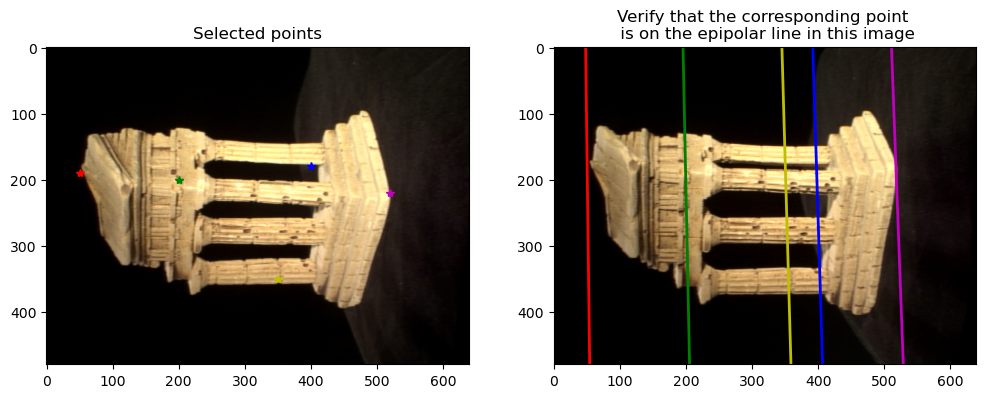

In [5]:
# im1 中需要验证其在 im2 中对应对极线的点
point = [(50,190),(200, 200), (400,180), (350,350), (520, 220)]
# 你可以修改这些点，以验证不同的点对应关系
displayEpipolarF(im1, im2, F, point)

# 问题 3：度量重建（40 分）


## 3.1 本质矩阵 [10 分]


In [6]:

def essentialMatrix(F, K1, K2):
  '''
  Q3.1：计算本质矩阵 E。
    输入：  F，基础矩阵
            K1，相机 1 的内参矩阵
            K2，相机 2 的内参矩阵
    输出： E，本质矩阵
  '''

  # E = K2^T * F * K1
  E = K2.T @ F @ K1
  E = E / E[2, 2]

  return E

运行以下代码检查你的实现。


In [7]:
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))
E = essentialMatrix(F, K1, K2)
print(f'恢复得到的 E:\n{E.round(4)}')

# 简单测试：检查你的实现
assert(E[2, 2] == 1)
assert(np.linalg.matrix_rank(E) == 2)

恢复得到的 E:
[[-3.3716000e+00  4.5661580e+02 -2.4738947e+03]
 [ 1.9760420e+02 -1.0290300e+01  6.4396600e+01]
 [ 2.4807427e+03  1.9856400e+01  1.0000000e+00]]


# 3.2 三角化 [15 分]



In [8]:
def triangulate(C1, pts1, C2, pts2):
  '''
  Q3.2：将图像中的一组二维坐标三角化为一组三维点。
  输入：  C1，3x4 相机矩阵
          pts1，Nx2 矩阵，每行是图像 1 中的二维坐标
          C2，3x4 相机矩阵
          pts2，Nx2 矩阵，每行是图像 2 中的二维坐标
  输出： P，Nx3 矩阵，每行是对应的三维点
          err，重投影误差。

  提示：
  (1) 对每个输入点，根据 pts1、pts2、C1、C2 构造矩阵 A。
  (2) Solve for the least square solution using np.linalg.svd
  (3) 使用计算得到的三维点以及 C1、C2 计算重投影误差。
      注意需要从齐次坐标转换回非齐次坐标。
  (4) 记录三维点与投影误差，然后继续处理下一个点。
  (5) 你不必严格遵循以上步骤。
  '''

  N = pts1.shape[0]
  P = np.zeros((N, 3))
  err = 0

  for i in range(N):
    x1, y1 = pts1[i, 0], pts1[i, 1]
    x2, y2 = pts2[i, 0], pts2[i, 1]

    # 构造 4x4 矩阵 A：
    # x * p3^T - p1^T (对 C1)
    # y * p3^T - p2^T (对 C1)
    # x' * p3'^T - p1'^T (对 C2)
    # y' * p3'^T - p2'^T (对 C2)
    A = np.array([
        x1 * C1[2, :] - C1[0, :],
        y1 * C1[2, :] - C1[1, :],
        x2 * C2[2, :] - C2[0, :],
        y2 * C2[2, :] - C2[1, :]
    ])

    # SVD 求解齐次最小二乘
    _, _, Vt = np.linalg.svd(A)
    w = Vt[-1, :]
    w = w / w[3]  # 齐次坐标归一化

    P[i, :] = w[:3]

    # 计算重投影误差
    proj1 = C1 @ w
    proj1 = proj1[:2] / proj1[2]
    proj2 = C2 @ w
    proj2 = proj2[:2] / proj2[2]

    err += np.sum((proj1 - pts1[i, :])**2) + np.sum((proj2 - pts2[i, :])**2)

  return P, err

## 3.3 寻找 M2 [15 分]


In [9]:
def camera2(E):
  """辅助函数：根据本质矩阵 E 找到 4 个可能的 M2 矩阵。"""
  U,S,V = np.linalg.svd(E)
  m = S[:2].mean()
  E = U.dot(np.array([[m,0,0], [0,m,0], [0,0,0]])).dot(V)
  U,S,V = np.linalg.svd(E)
  W = np.array([[0,-1,0], [1,0,0], [0,0,1]])

  if np.linalg.det(U.dot(W).dot(V))<0:
      W = -W

  M2s = np.zeros([3,4,4])
  M2s[:,:,0] = np.concatenate([U.dot(W).dot(V), U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
  M2s[:,:,1] = np.concatenate([U.dot(W).dot(V), -U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
  M2s[:,:,2] = np.concatenate([U.dot(W.T).dot(V), U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
  M2s[:,:,3] = np.concatenate([U.dot(W.T).dot(V), -U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
  return M2s


def findM2(F, pts1, pts2, intrinsics):
    '''
    Q3.3：根据对应点寻找第二个相机的投影矩阵。
        输入：  F, 预先计算好的基础矩阵
                pts1，Nx2 矩阵，每行是图像 1 中的二维坐标
                pts2，Nx2 矩阵，每行是图像 2 中的二维坐标
                intrinsics, 相机内参字典，从 .npz 文件中加载
                filename，用于保存结果的文件名（本版本无需使用）
        输出： [M2, C2, P] 计算得到的 M2（3x4）相机外参矩阵、C2（3x4）= K2 * M2，以及三维点 P（Nx3）

    ***
    提示：
    (1) 遍历 `M2s`，使用 triangulate 计算三维点和投影误差。需要记录哪一个解使点位于相机前方（z 为正）。
    (2) 查看 camera2 函数，理解如何从 `M2s` 中正确取出候选 M2。

    '''

    K1, K2 = intrinsics['K1'], intrinsics['K2']

    # 计算本质矩阵
    E = essentialMatrix(F, K1, K2)

    # M1 = [I | 0]
    M1 = np.hstack((np.eye(3), np.zeros((3, 1))))
    C1 = K1 @ M1

    # 获取 4 个候选 M2
    M2s = camera2(E)

    best_M2 = None
    best_C2 = None
    best_P = None
    best_err = np.inf

    for k in range(4):
        M2_candidate = M2s[:, :, k]
        C2_candidate = K2 @ M2_candidate

        P_candidate, err_candidate = triangulate(C1, pts1, C2_candidate, pts2)

        # 检查所有点在两个相机前方（z > 0）
        # 对 camera1: z = P[:, 2] （因为 M1=[I|0]，相机坐标就是世界坐标）
        # 对 camera2: 需要将点变换到 camera2 坐标系
        P_homo = np.hstack((P_candidate, np.ones((P_candidate.shape[0], 1))))
        P_in_cam2 = (M2_candidate @ P_homo.T).T

        if np.all(P_candidate[:, 2] > 0) and np.all(P_in_cam2[:, 2] > 0):
            if err_candidate < best_err:
                best_err = err_candidate
                best_M2 = M2_candidate
                best_C2 = C2_candidate
                best_P = P_candidate

    M2 = best_M2
    C2 = best_C2
    P = best_P

    return M2, C2, P

运行以下代码检查 triangulate 和 findM2 的实现。


In [10]:
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))

M2, C2, P = findM2(F, pts1, pts2, intrinsics)

# 简单测试：检查你的实现
M1 = np.hstack((np.identity(3), np.zeros(3)[:,np.newaxis]))
C1 = K1.dot(M1)
C2 = K2.dot(M2)
P_test, err = triangulate(C1, pts1, C2, pts2)
assert(err < 500)

# 问题 4：三维可视化（25 分）


In [11]:
def epipolarCorrespondence(im1, im2, F, x1, y1):
  '''
  Q4.1：Temple 对极线对应点搜索。
  输入：  im1，第一张图像
          im2，第二张图像
          F，基础矩阵
          x1，im1 中待匹配点的 x 坐标
          y1，im1 中待匹配点的 y 坐标
  输出：  x2，im2 中对应点的 x 坐标
          y2，im2 中对应点的 y 坐标

  ???
  提示：
  (1) 根据 [x1, y1] 和 F 计算 im2 中对应的对极线。
  (2) 沿着对极线搜索候选点，并比较 im1 与 im2 中的局部窗口。
  (3) 选择匹配代价最小的候选点作为对应点。
  '''
  def _to_gray(im):
    im = im.astype(np.float64)
    if im.max() > 1:
      im = im / 255.0
    if im.ndim == 3:
      im = 0.299 * im[:, :, 0] + 0.587 * im[:, :, 1] + 0.114 * im[:, :, 2]
    return im

  window_size = 5
  search_range = 120
  I1 = _to_gray(im1)
  I2 = _to_gray(im2)
  h, w = I2.shape[:2]

  x1, y1 = int(round(x1)), int(round(y1))
  if (x1 - window_size < 0 or x1 + window_size >= I1.shape[1] or
      y1 - window_size < 0 or y1 + window_size >= I1.shape[0]):
    return x1, y1

  patch1 = I1[y1 - window_size:y1 + window_size + 1,
              x1 - window_size:x1 + window_size + 1]
  grid_y, grid_x = np.mgrid[-window_size:window_size + 1,
                            -window_size:window_size + 1]
  gaussian_weight = np.exp(-(grid_x ** 2 + grid_y ** 2) / (2 * 3.0 ** 2))

  line = F @ np.array([x1, y1, 1.0])
  best_cost = np.inf
  best_point = (x1, y1)

  # 根据对极线斜率选择遍历 y 或 x，避免数值不稳定。
  if abs(line[0]) > abs(line[1]):
    for y_cand in range(max(window_size, y1 - search_range),
                        min(h - window_size, y1 + search_range + 1)):
      x_cand = int(round(-(line[1] * y_cand + line[2]) / line[0]))
      if x_cand < window_size or x_cand >= w - window_size:
        continue
      patch2 = I2[y_cand - window_size:y_cand + window_size + 1,
                  x_cand - window_size:x_cand + window_size + 1]
      cost = np.sum(gaussian_weight * (patch1 - patch2) ** 2)
      if cost < best_cost:
        best_cost = cost
        best_point = (x_cand, y_cand)
  else:
    for x_cand in range(max(window_size, x1 - search_range),
                        min(w - window_size, x1 + search_range + 1)):
      y_cand = int(round(-(line[0] * x_cand + line[2]) / line[1]))
      if y_cand < window_size or y_cand >= h - window_size:
        continue
      patch2 = I2[y_cand - window_size:y_cand + window_size + 1,
                  x_cand - window_size:x_cand + window_size + 1]
      cost = np.sum(gaussian_weight * (patch1 - patch2) ** 2)
      if cost < best_cost:
        best_cost = cost
        best_point = (x_cand, y_cand)

  return best_point[0], best_point[1]


运行以下代码检查你的实现。


In [12]:
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))

# 简单测试：检查你的实现
x2, y2 = epipolarCorrespondence(im1, im2, F, 119, 217)
assert(np.linalg.norm(np.array([x2, y2]) - np.array([118, 181])) < 10)

使用下面的工具调试你的代码。


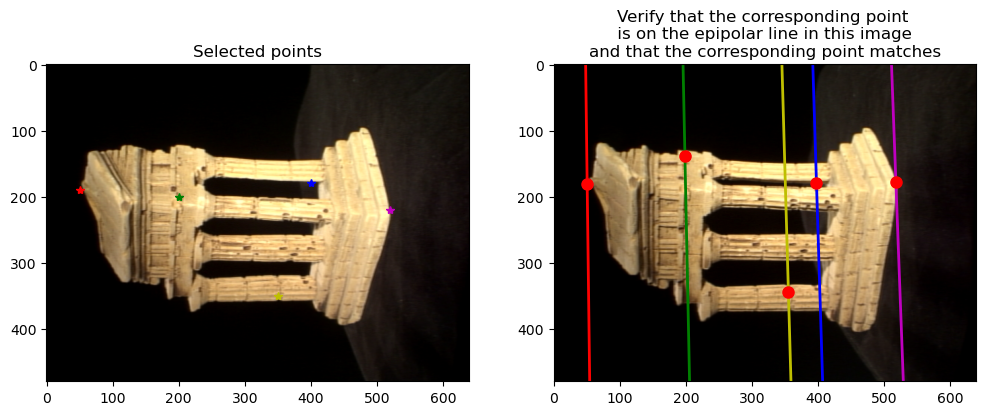

In [13]:
# im1 中需要验证其在 im2 中对应对极线和匹配点的点
points = [(50,190), (200, 200), (400,180), (350,350), (520, 220)]
# 你可以修改这些点，以验证不同的点对应关系
epipolarMatchGUI(im1, im2, F, points, epipolarCorrespondence)

## 4.2 Temple 三维可视化 [10 分]


In [14]:
def compute3D_pts(temple_pts1, intrinsics, F, im1, im2):
  '''
  Q4.2：基于对极对应和三角化，寻找给定点的三维位置。
  输入：  temple_pts1，从 im1 中选出的点
          intrinsics，用于调用 epipolarCorrespondence 的相机内参字典
          F，基础矩阵
          im1，第一张图像
          im2，第二张图像
  输出： P，Nx3 矩阵，恢复出的三维点

  提示：
  (1) 使用 epipolarCorrespondence 为 [x1, y1] 找到对应点 [x2, y2]。
  (2) 得到一组对应点 [x1, y1] 与 [x2, y2] 后，可以计算 M2 矩阵，
      并使用 triangulate 求出三维点。
  (3) 使用 findM2 函数求三维点 P（不要重新计算基础矩阵）。
  (4) 作为参考，我们的解在这些三维点上的最佳误差约为 2200。
  '''
  K1, K2 = intrinsics['K1'], intrinsics['K2']
  N = temple_pts1.shape[0]

  # 使用 epipolarCorrespondence 为每个 im1 中的点找到 im2 中的对应点
  pts2 = np.zeros((N, 2))
  for i in range(N):
    x1_i, y1_i = temple_pts1[i, 0], temple_pts1[i, 1]
    x2_i, y2_i = epipolarCorrespondence(im1, im2, F, x1_i, y1_i)
    pts2[i, :] = [x2_i, y2_i]

  # 使用 findM2 得到正确的 M2 和三维点
  M2, C2, _ = findM2(F, temple_pts1, pts2, intrinsics)

  # 重新三角化得到最终的三维点
  M1 = np.hstack((np.eye(3), np.zeros((3, 1))))
  C1 = K1 @ M1
  C2 = K2 @ M2
  P, err = triangulate(C1, temple_pts1, C2, pts2)

  print(f'重投影误差: {err:.2f}')

  return P


下面将所有部分整合起来。
提供的 starter code 会加载 `data/templeCoords.npz` 中的 temple 数据，其中包含从 im1 中手工选出的 288 个点，变量名为 x1 和 y1。
接着，调用你刚实现的函数和其他必要函数，从二维点对应关系得到三维点。最后，使用 matplotlib 或 plotly 的三维散点图可视化三维重建结果。




重投影误差: 726.45


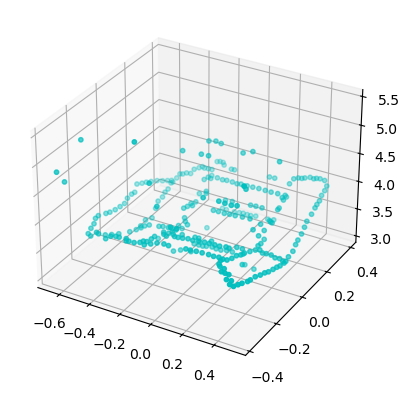

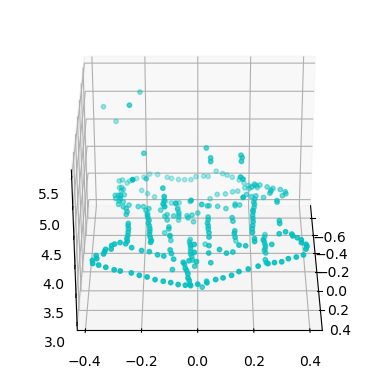

In [15]:
temple_coords = np.load('data/templeCoords.npz') # 加载 temple 坐标
correspondence = np.load('data/some_corresp.npz') # 加载对应点
intrinsics = np.load('data/intrinsics.npz') # 加载相机内参
K1, K2 = intrinsics['K1'], intrinsics['K2']
pts1, pts2 = correspondence['pts1'], correspondence['pts2']
im1 = plt.imread('data/im1.png')
im2 = plt.imread('data/im2.png')

# ----- TODO -----
# 调用 eightpoint 得到 F 矩阵
# 调用 compute3D_pts 得到三维点，并使用 matplotlib scatter 进行可视化
# 提示：你可以使用下面的方法改变 matplotlib 3D 坐标轴视角：
# `ax.view_init(azim, elev)` where azim is the rotation around the vertical z
# axis, and elev is the angle of elevation from the x-y plane

temple_pts1 = np.hstack([temple_coords['x1'], temple_coords['y1']])

# 计算基础矩阵
F = eightpoint(pts1, pts2, M=np.max([*im1.shape, *im2.shape]))

# 计算三维点
P = compute3D_pts(temple_pts1, intrinsics, F, im1, im2)

# 代码结束

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=10, c='c', depthshade=True)
plt.draw()

# 再展示一个不同视角
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=10, c='c', depthshade=True)
ax.view_init(30, 0)
plt.draw()
